# 🥁 Drum Kit Classification: The Cassette Challenge
This notebook tests various Machine Learning and Deep Learning approaches to classify drum samples that have been intentionally degraded using temporal jitter, white noise, and cassette tape emulation (wow, flutter, and saturation). 

**Goal:** Identify the correct drum kit (Black Oyster, Dead Vintage, Hiphop Gospel, Soul RnB) from highly noisy, non-static spectrograms.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-Learn (Traditional ML)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from skimage.feature import hog

# PyTorch (Deep Learning)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import torch.nn.functional as F

import warnings
warnings.filterwarnings('ignore')

## Part 1: Traditional Machine Learning (Flattened Pixels)
First, we establish a baseline using traditional models. We resize the images to $64 \times 64$ to average out the high-frequency cassette hiss, flatten them into 1D arrays, and test Logistic Regression and a Random Forest.

In [2]:
# 1. Load and Flatten Images
def load_flat_images(img_folder, size=(64, 64)):
    X, y = [], []
    classes = sorted([d for d in os.listdir(img_folder) if not d.startswith('.')])
    
    for idx, cls in enumerate(classes):
        cls_path = os.path.join(img_folder, cls)
        for img_name in os.listdir(cls_path):
            if img_name.endswith('.png'):
                img = Image.open(os.path.join(cls_path, img_name)).convert('L')
                img = img.resize(size)
                X.append(np.array(img).flatten())
                y.append(idx)
    return np.array(X), np.array(y), classes

print("Loading dataset for Traditional ML...")
X_flat, y_flat, class_names = load_flat_images("dataset/images")

# 2. Scale and Split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_flat, test_size=0.2, random_state=42)

# 3. Train Baselines
lr_model = LogisticRegression(max_iter=1000, C=0.1)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print(f"Logistic Regression Accuracy: {lr_model.score(X_test, y_test) * 100:.2f}%")
print(f"Random Forest Accuracy: {rf_model.score(X_test, y_test) * 100:.2f}%")

Loading dataset for Traditional ML...
Logistic Regression Accuracy: 87.92%
Random Forest Accuracy: 87.92%


## Part 2: The "Dream Team" Ensemble
Since different models look for different things (Linear vs. Tree-based vs. Spatial), we combine them into a Voting Classifier to see if teamwork can beat the noise.

In [3]:
svc_model = SVC(probability=True, kernel='rbf', random_state=42)

ensemble = VotingClassifier(
    estimators=[('lr', lr_model), ('rf', rf_model), ('svc', svc_model)],
    voting='soft'
)

print("Training the Ensemble...")
ensemble.fit(X_train, y_train)
print(f"Ensemble Test Accuracy: {ensemble.score(X_test, y_test) * 100:.2f}%")

Training the Ensemble...
Ensemble Test Accuracy: 90.00%


## Part 3: Deep Learning (Convolutional Neural Network)
Traditional ML struggles with the spatial shift (jitter) in our spectrograms. Here, we build a Custom CNN using PyTorch and Apple Metal Performance Shaders (MPS) to learn translation-invariant shapes.

Using device: mps
Training CNN...
CNN Final Accuracy: 96.67%


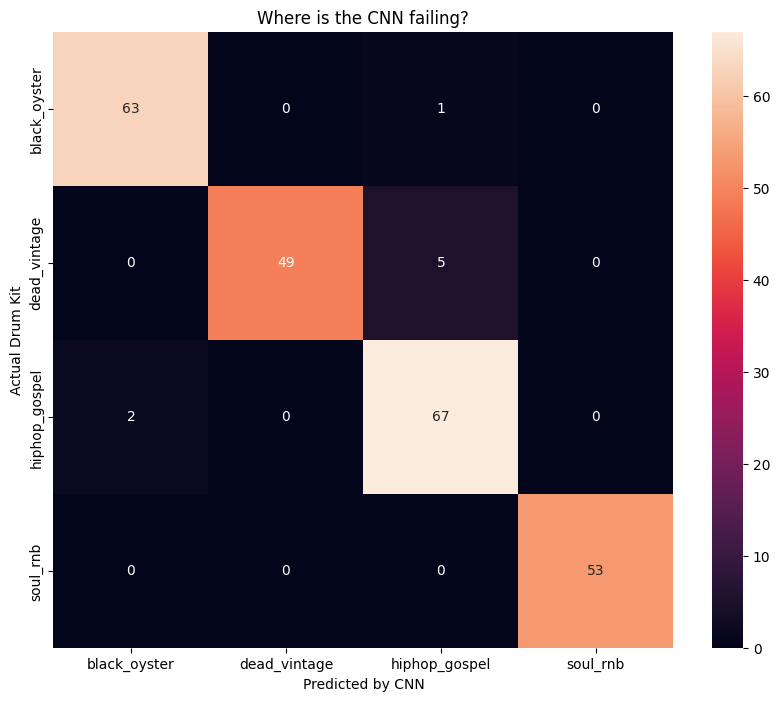

In [4]:
# 1. Device Setup
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# 2. PyTorch Data Loaders (128x128 resolution)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(root="dataset/images", transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 3. Model Definition
class DrumCNN(nn.Module):
    def __init__(self, num_classes):
        super(DrumCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

# 4. Training Loop
cnn_model = DrumCNN(len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

print("Training CNN...")
for epoch in range(15): # Reduced for brevity
    cnn_model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(cnn_model(images), labels)
        loss.backward()
        optimizer.step()

# 5. Evaluation
cnn_model.eval()
cnn_correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, preds = torch.max(cnn_model(images), 1)
        cnn_correct += (preds == labels).sum().item()

cnn_acc = (cnn_correct / test_size) * 100
print(f"CNN Final Accuracy: {cnn_acc:.2f}%")

from sklearn.metrics import confusion_matrix
import seaborn as sns

cnn_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = cnn_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create the matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel('Predicted by CNN')
plt.ylabel('Actual Drum Kit')
plt.title('Where is the CNN failing?')
plt.show()

## Part 4: Advanced Feature Engineering (HOG + Gradient Boosting)
To filter out the random "tape hiss" but keep the sharp drum transients, we extract Histogram of Oriented Gradients (HOG) features and feed them to a powerful Gradient Boosting Classifier.

In [5]:
def extract_hog_features(img_folder):
    X_hog, y_hog = [], []
    for idx, cls in enumerate(class_names):
        cls_path = os.path.join(img_folder, cls)
        for img_name in os.listdir(cls_path):
            if img_name.endswith('.png'):
                img_array = np.array(Image.open(os.path.join(cls_path, img_name)).convert('L').resize((64, 64)))
                
                # Extract shapes, ignore noise
                fd = hog(img_array, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1), visualize=False)
                raw = img_array.flatten() / 255.0
                
                X_hog.append(np.hstack([raw, fd]))
                y_hog.append(idx)
    return np.array(X_hog), np.array(y_hog)

print("Extracting HOG features...")
X_h, y_h = extract_hog_features("dataset/images")
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=3)
gb_model.fit(X_h_train, y_h_train)

gb_acc = gb_model.score(X_h_test, y_h_test) * 100
print(f"HOG + Gradient Boosting Accuracy: {gb_acc:.2f}%")

Extracting HOG features...
HOG + Gradient Boosting Accuracy: 92.08%


# Part 5 - ResNet

Starting Training for 4 kits...
Epoch [1/15], Loss: 0.9006
Epoch [2/15], Loss: 0.6052
Epoch [3/15], Loss: 0.4818
Epoch [4/15], Loss: 0.3850
Epoch [5/15], Loss: 0.3177
Epoch [6/15], Loss: 0.2448
Epoch [7/15], Loss: 0.2428
Epoch [8/15], Loss: 0.2585
Epoch [9/15], Loss: 0.1745
Epoch [10/15], Loss: 0.1353
Epoch [11/15], Loss: 0.1180
Epoch [12/15], Loss: 0.1359
Epoch [13/15], Loss: 0.0700
Epoch [14/15], Loss: 0.0998
Epoch [15/15], Loss: 0.1261

Final Test Accuracy: 86.25%


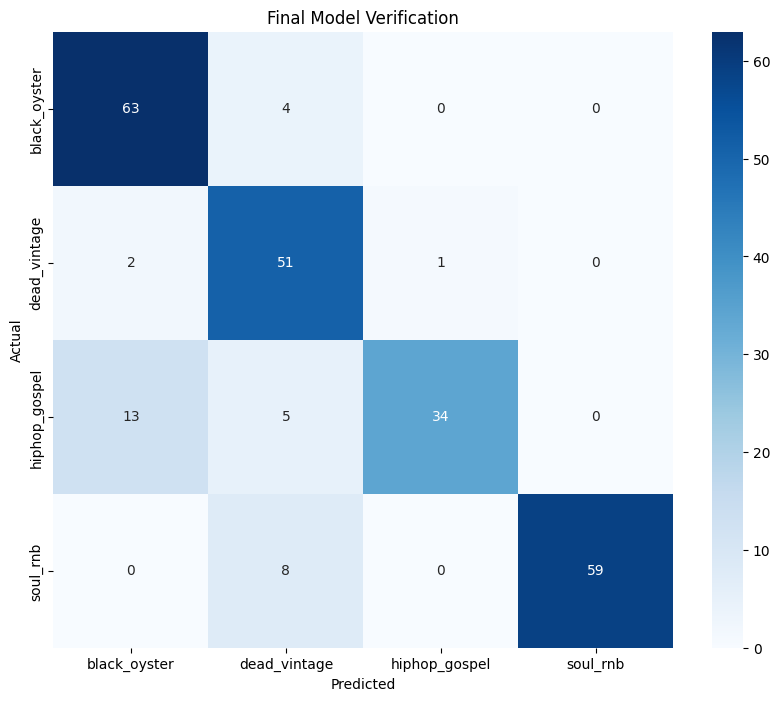

In [6]:
# Resizing to 128x128 provides enough detail for the ResNet to find drum 'DNA'
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load from your generated images folder
DATA_PATH = "dataset/images" 
full_dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_data, test_data = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 3. RESNET ARCHITECTURE (The 'Heavy Lifter')
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class DrumResNet(nn.Module):
    def __init__(self, num_classes):
        super(DrumResNet, self).__init__()
        self.in_channels = 16
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        
        # Three layers of increasing depth
        self.layer1 = ResidualBlock(16, 32, stride=2)  # 64x64
        self.layer2 = ResidualBlock(32, 64, stride=2)  # 32x32
        self.layer3 = ResidualBlock(64, 128, stride=2) # 16x16
        
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        return self.fc(out)

# 4. INITIALIZE MODEL
num_classes = len(full_dataset.classes)
res_model = DrumResNet(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(res_model.parameters(), lr=0.001)

# 5. TRAINING LOOP
epochs = 15 # Increased slightly to find that last 4%
print(f"Starting Training for {num_classes} kits...")

for epoch in range(epochs):
    res_model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = res_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

# 6. EVALUATION & CONFUSION MATRIX
res_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = res_model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

res_acc = 100 * sum([p == l for p, l in zip(all_preds, all_labels)]) / len(all_labels)
print(f"\nFinal Test Accuracy: {res_acc:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=full_dataset.classes, yticklabels=full_dataset.classes, cmap='Blues')
plt.title('Final Model Verification')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Part 6: Model Leaderboard
Let's see how all the approaches stack up against each other!

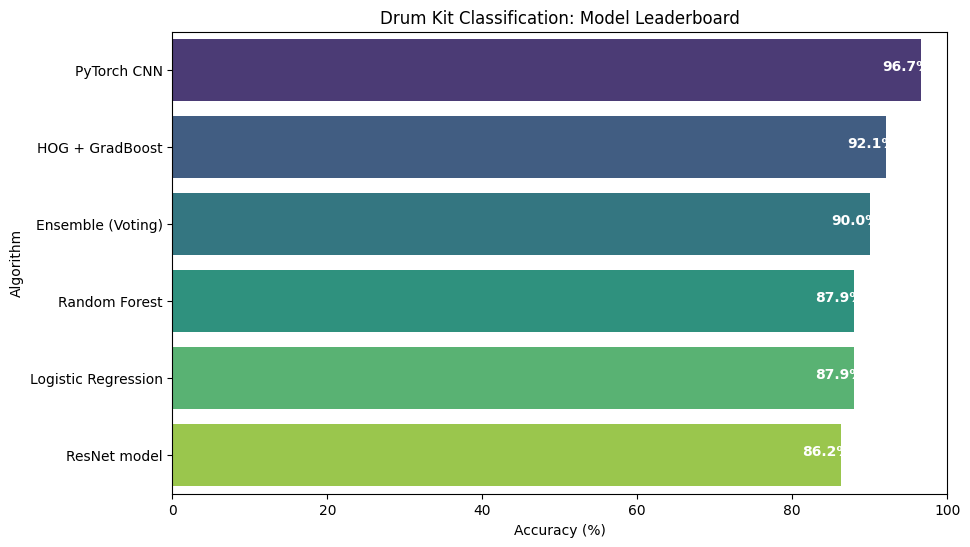

In [7]:
results = {
    "Random Forest": rf_model.score(X_test, y_test) * 100,
    "Logistic Regression": lr_model.score(X_test, y_test) * 100,
    "Ensemble (Voting)": ensemble.score(X_test, y_test) * 100,
    "PyTorch CNN": cnn_acc,
    "HOG + GradBoost": gb_acc,
    "ResNet model": res_acc
}

results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Drum Kit Classification: Model Leaderboard')
plt.xlim(0, 100)
plt.xlabel('Accuracy (%)')
plt.ylabel('Algorithm')
for index, value in enumerate(results_df['Accuracy']):
    plt.text(value - 5, index, f'{value:.1f}%', color='white', weight='bold')
plt.show()

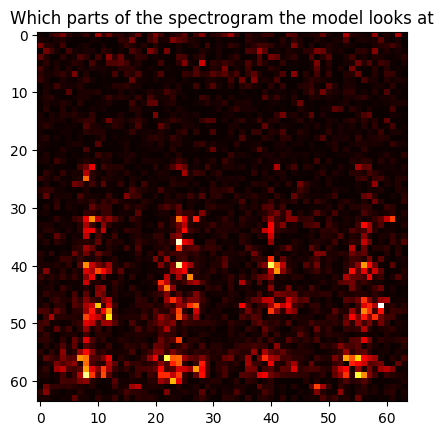

In [8]:
importances = rf_model.feature_importances_.reshape(64, 64, -1)
plt.imshow(importances, cmap='hot')
plt.title("Which parts of the spectrogram the model looks at")
plt.show()